# Dark-matter quantum-sensor response analysis

Forward + inverse analysis of the detector response, organised **by detector**
and, within each, **by velocity-distribution model**. Same pipeline throughout
(load Mathematica response matrix -> forward model `exposure * M @ eta` ->
recover the monotone non-negative flux `x(v_min)`); only two things change:

- **detector** (`material`): **TES (Al)** -- Mermin, 0.1 eV threshold, fine `R10`;
  **MKID (TiN)** -- Lindhard, 0.2 eV threshold, fine `R9`.
- **velocity model**: **Halo** -- standard halo (SHM, `v0=238, ve=250, vesc=544`
  km/s); **pure dark disk** -- same DM density, colder (`v0=70, ve=100,
  vesc=694`). The actual **best-fit uses a mixture** `eta = (1-p)*Halo + p*Disk`
  with disk fraction `p`; because both components carry the same local DM
  density, the mixture's density equals 100% SHM for any `p`. A third model,
  **Bound** (Earth-captured thermal DM), is a separate dense population
  (`rho_b`, isotropic, `vesc=11.2` km/s) -- only the heaviest mass (1 GeV) has
  any signal, since the bound DM is too slow to reach higher `v_min`.

The mixture sections sweep `p` over `DISK_FRACTIONS` and overlay, on each fit,
the **100% SHM** halo and the **`p` x pure disk** component for reference.


In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
from quantum_sensor import DarkMatterQuantumAnalysis, RunConfig

MASS_LABELS = {'1': '10 MeV', '2': '100 MeV', '3': '1 GeV'}
DETECTOR = {'Al': 'TES', 'TiN': 'MKID'}
# Dark-disk mixing fractions p for the best-fit eta = (1-p)*Halo + p*Disk.
DISK_FRACTIONS = (0.05, 0.25)


def run_masses(material, q='0', nbins=5, eta='Halo', background='none',
               disk_fraction=None, masses=('1', '2', '3'), solver='osqp', save=True):
    """Run the forward+inverse analysis for several DM masses.

    Shows one combined figure (the masses side by side). When ``save=True``
    (default) each run is ALSO saved on its own -- flux.csv plus an individual
    flux.pdf -- into its per-run folder
    results/<DET>/bkg-<background>/<material>_q<q>_M<mass>_R<nbins>_<eta>/, so
    every type is stored separately regardless of the combined display.
    """
    fig, axes = plt.subplots(1, len(masses), figsize=(6 * len(masses), 5), squeeze=False)
    for ax, mass in zip(axes[0], masses):
        a = DarkMatterQuantumAnalysis(
            RunConfig(material=material, q=q, mass=mass, nbins=nbins,
                      eta=eta, disk_fraction=disk_fraction, background=background))
        flux = a.optimize(solver=solver)
        print('signal     :', a.signal)
        print('background :', a.background)

        if save:
            a.save_flux()                     # flux.csv in this run's own folder
            sfig, sax = plt.subplots(figsize=(8, 6))
            a.plot(save=True, ax=sax)         # individual flux.pdf next to the CSV
            plt.close(sfig)                   # keep only the combined figure on screen

        a.plot(save=False, ax=ax)             # combined panel (display only)
        ax.set_title(f'{material} ({DETECTOR[material]}), $m_\\chi$ = {MASS_LABELS[mass]}',
                     fontsize=13)
        print(f'{material} q{q} M{mass} R{nbins}: {a.n_ebins} E-bins x '
              f'{a.n_vmin} v_min bins, peak flux {flux.max():.2e}')
    model = eta if disk_fraction is None else f'mix {round(disk_fraction*100)}% disk'
    fig.suptitle(f'{material} ({DETECTOR[material]}), q{q}, R{nbins}, {model}, bkg={background}',
                 fontsize=14)
    plt.tight_layout(); plt.show()


# TES (Al)

## Halo (SHM) — reference

### Heavy mediator (q0), 5 energy bins

signal     : [1412.52911899 2819.10531101 4114.88291643 5395.20086016 6519.33435773]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q0_M1_R5_Halo/flux.pdf
Al q0 M1 R5: 5 E-bins x 130 v_min bins, peak flux 7.83e-31
signal     : [148.72936743 286.12914202 428.01488718 561.3399321  688.91644664]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q0_M2_R5_Halo/flux.pdf
Al q0 M2 R5: 5 E-bins x 63 v_min bins, peak flux 8.26e-32
signal     : [14.57845243 27.38823471 42.52742334 55.38644181 68.00784404]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q0_M3_R5_Halo/flux.pdf
Al q0 M3 R5: 5 E-bins x 64 v_min bins, peak flux 8.28e-33


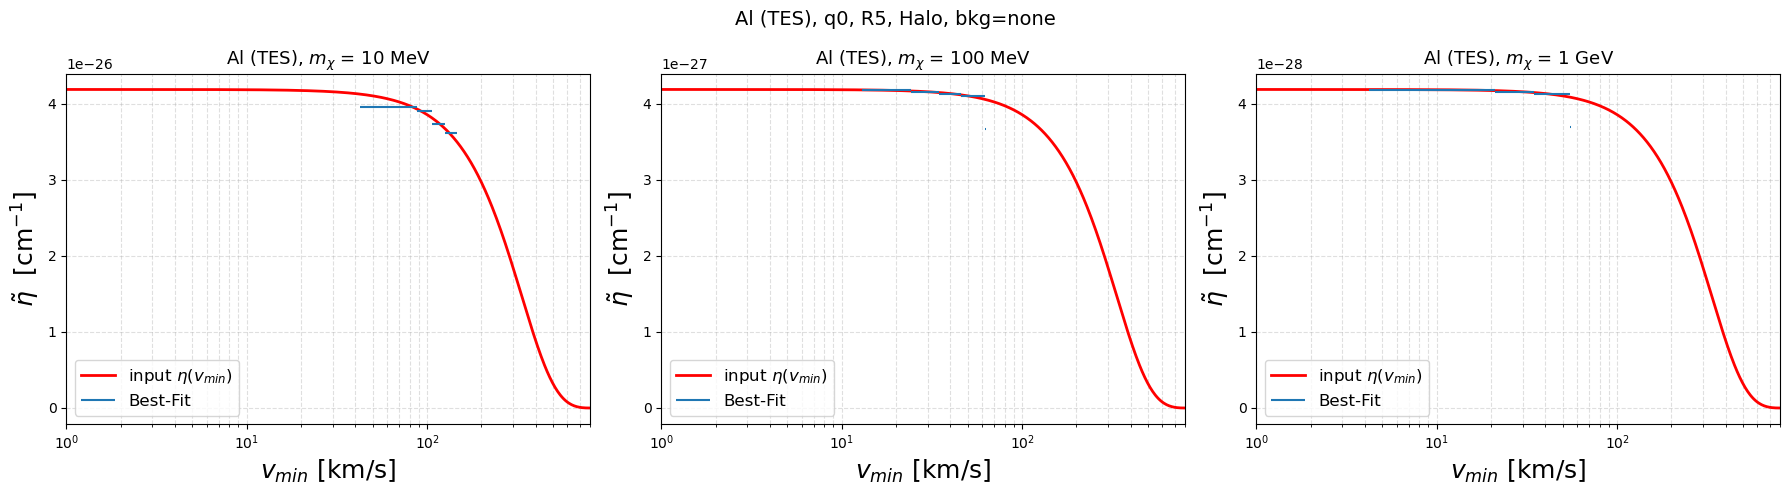

In [ ]:
run_masses('Al', q='0', nbins=5, eta='Halo', solver = 'scipy')

### Light mediator (q2), 5 energy bins

signal     : [1362.03322362 2563.95126029 3621.13872896 4509.97437384 5257.42449272]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q2_M1_R5_Halo/flux.pdf
Al q2 M1 R5: 5 E-bins x 210 v_min bins, peak flux 8.00e-31
signal     : [128.99687548 247.60323028 353.30862736 446.90441419 527.6480368 ]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q2_M2_R5_Halo/flux.pdf
Al q2 M2 R5: 5 E-bins x 219 v_min bins, peak flux 8.26e-32
signal     : [12.72943263 24.53959016 35.10107731 44.48830266 52.62422455]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q2_M3_R5_Halo/flux.pdf
Al q2 M3 R5: 5 E-bins x 227 v_min bins, peak flux 8.30e-33


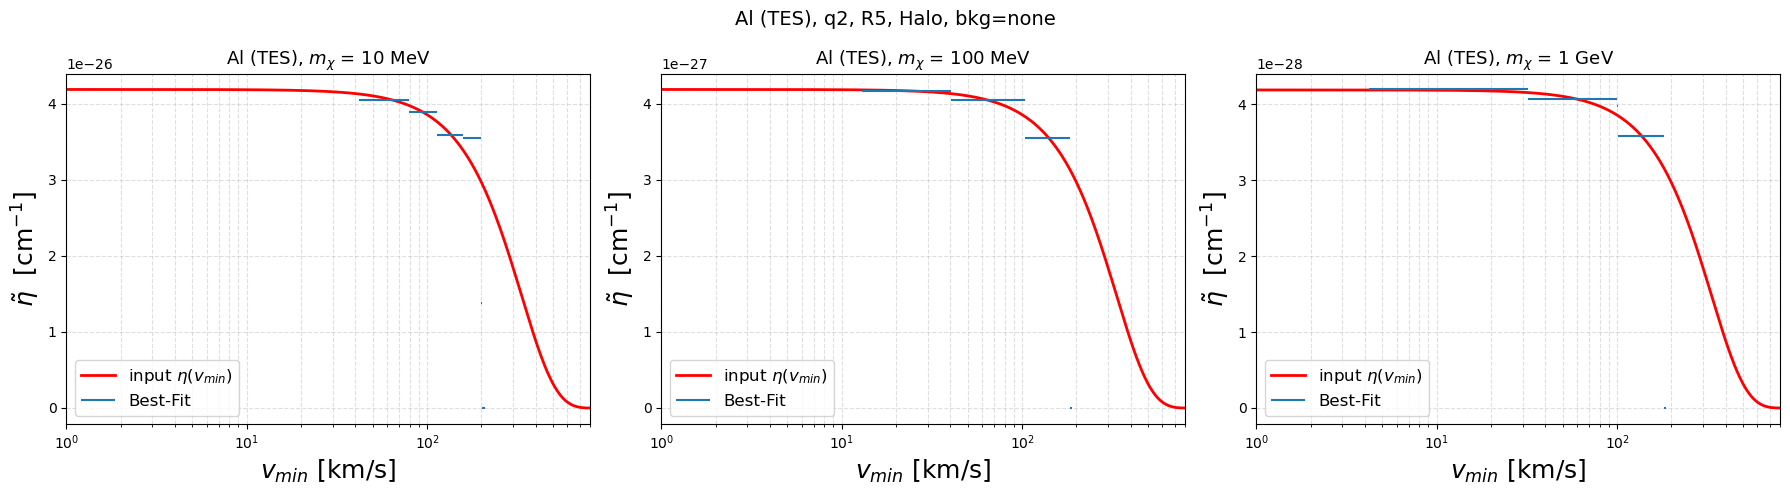

In [28]:
run_masses('Al', q='2', nbins=5, eta='Halo', solver = 'scipy')

### Heavy mediator (q0), 10 energy bins

signal     : [ 563.36869448  933.95482521 1292.50133021 1642.2350279  1986.30907968
 2299.81199488 2685.87344361 2965.60214435 3214.00339556 3552.62491926]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q0_M1_R10_Halo/flux.pdf
Al q0 M1 R10: 10 E-bins x 132 v_min bins, peak flux 7.94e-31
signal     : [ 61.77562826  92.38384157 126.71857849 166.78772516 202.32216648
 237.31888526 270.36253941 303.67726966 337.03218576 379.49830011]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q0_M2_R10_Halo/flux.pdf
Al q0 M2 R10: 10 E-bins x 66 v_min bins, peak flux 8.27e-32
signal     : [ 5.41329785  9.75328125 12.70792773 16.62287889 20.4507157  23.22679581
 27.04942923 30.826814   33.56062969 37.35667655]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/Quan

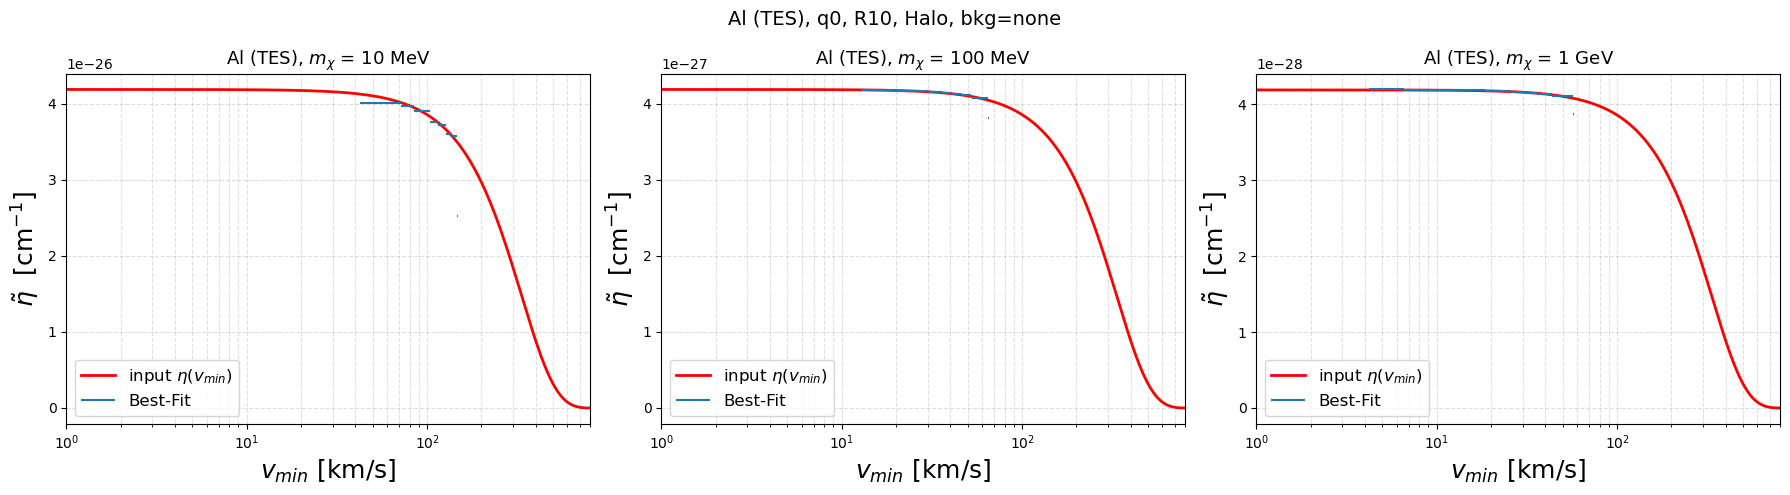

In [4]:
run_masses('Al', q='0', nbins=10, eta='Halo', solver = 'scipy')

### Light mediator (q2), 10 energy bins

signal     : [ 538.16963877  899.5316871  1204.0775039  1498.70049905 1771.54640982
 2020.59533105 2258.89412904 2471.02730928 2657.45358186 2859.27033863]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q2_M1_R10_Halo/flux.pdf
Al q2 M1 R10: 10 E-bins x 220 v_min bins, peak flux 8.06e-31
signal     : [ 50.23195123  84.42598541 114.97722652 143.99952517 171.80879782
 197.99347604 222.71854724 244.57359974 266.229305   286.32225897]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q2_M2_R10_Halo/flux.pdf
Al q2 M2 R10: 10 E-bins x 229 v_min bins, peak flux 8.25e-32
signal     : [ 5.00229797  8.34775273 11.38255302 14.36064778 17.05741023 19.76117058
 22.15854704 24.43714818 26.61587352 28.56763827]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/Qua

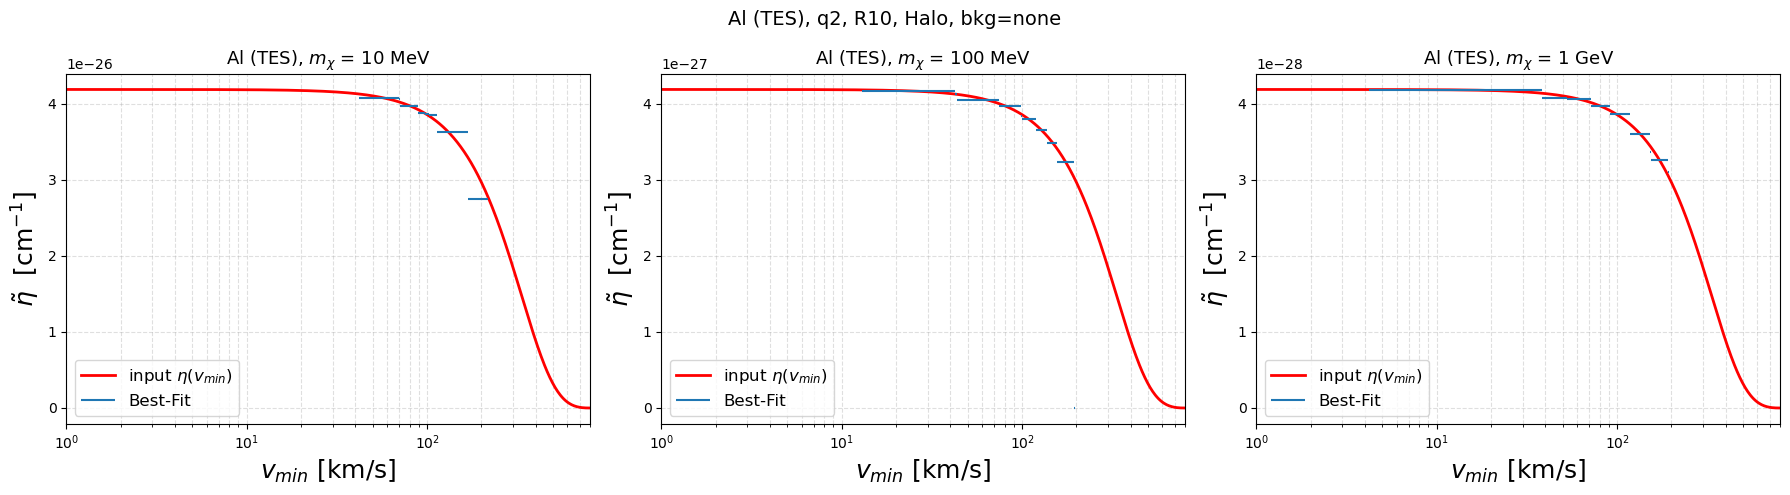

In [29]:
run_masses('Al', q='2', nbins=10, eta='Halo', solver = 'scipy')

## Mixture (best-fit) — sweep dark-disk fraction

`eta = (1-p)*Halo + p*Disk`. Each figure overlays 100% SHM (gray) and `p` x pure disk (green).

### Heavy mediator (q0), 5 energy bins

signal     : [1470.36189485 2896.12466541 4168.2608035  5390.55646681 6435.73207831]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q0_M1_R5_mix5/flux.pdf
Al q0 M1 R5: 5 E-bins x 130 v_min bins, peak flux 8.21e-31
signal     : [161.44391325 309.84711684 462.06966554 603.85037523 738.11828995]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q0_M2_R5_mix5/flux.pdf
Al q0 M2 R5: 5 E-bins x 63 v_min bins, peak flux 8.97e-32
signal     : [15.84839627 29.74898098 46.11925315 59.93766473 73.39343141]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q0_M3_R5_mix5/flux.pdf
Al q0 M3 R5: 5 E-bins x 64 v_min bins, peak flux 9.00e-33


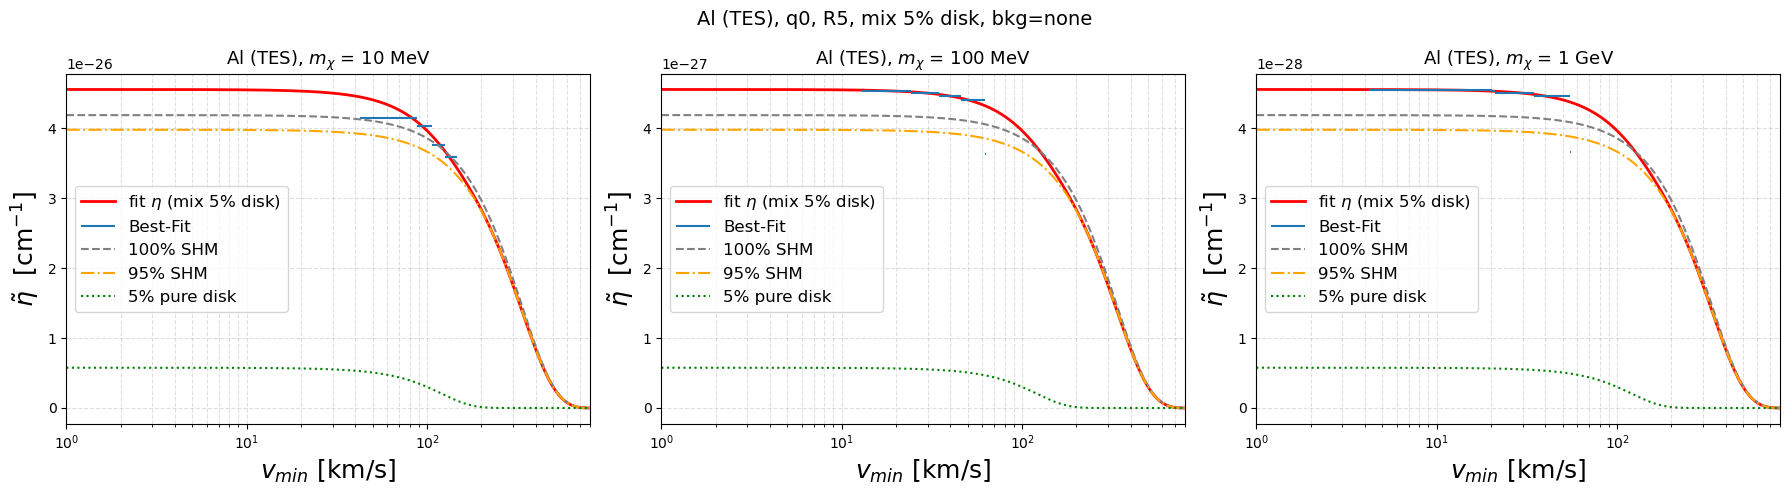

signal     : [1701.69299828 3204.20208299 4381.77235176 5371.97889343 6101.32296065]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q0_M1_R5_mix25/flux.pdf
Al q0 M1 R5: 5 E-bins x 130 v_min bins, peak flux 9.75e-31
signal     : [212.30209653 404.71901612 598.28877897 773.89214777 934.92566322]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q0_M2_R5_mix25/flux.pdf
Al q0 M2 R5: 5 E-bins x 63 v_min bins, peak flux 1.18e-31
signal     : [20.92817164 39.19196602 60.48657241 78.14255644 94.9357809 ]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q0_M3_R5_mix25/flux.pdf
Al q0 M3 R5: 5 E-bins x 64 v_min bins, peak flux 1.19e-32


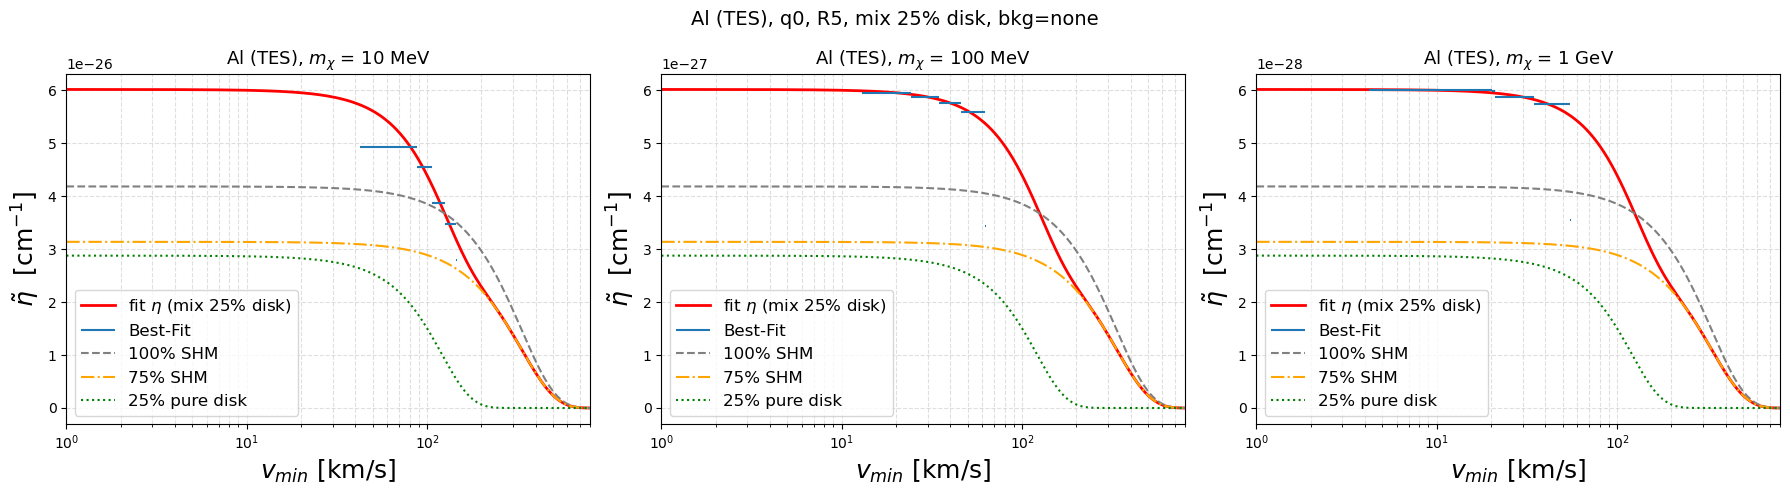

In [6]:
for p in DISK_FRACTIONS:
    run_masses('Al', q='0', nbins=5, disk_fraction=p, solver = 'scipy')

### Light mediator (q2), 5 energy bins

signal     : [1445.39972297 2657.53869744 3666.23003632 4474.57296797 5137.8381523 ]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q2_M1_R5_mix5/flux.pdf
Al q2 M1 R5: 5 E-bins x 210 v_min bins, peak flux 8.48e-31
signal     : [139.68400157 265.50814751 373.18010788 463.93727255 538.83992826]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q2_M2_R5_mix5/flux.pdf
Al q2 M2 R5: 5 E-bins x 219 v_min bins, peak flux 8.97e-32
signal     : [13.79803534 26.36686065 37.18542162 46.35311872 53.9576362 ]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q2_M3_R5_mix5/flux.pdf
Al q2 M3 R5: 5 E-bins x 227 v_min bins, peak flux 9.04e-33


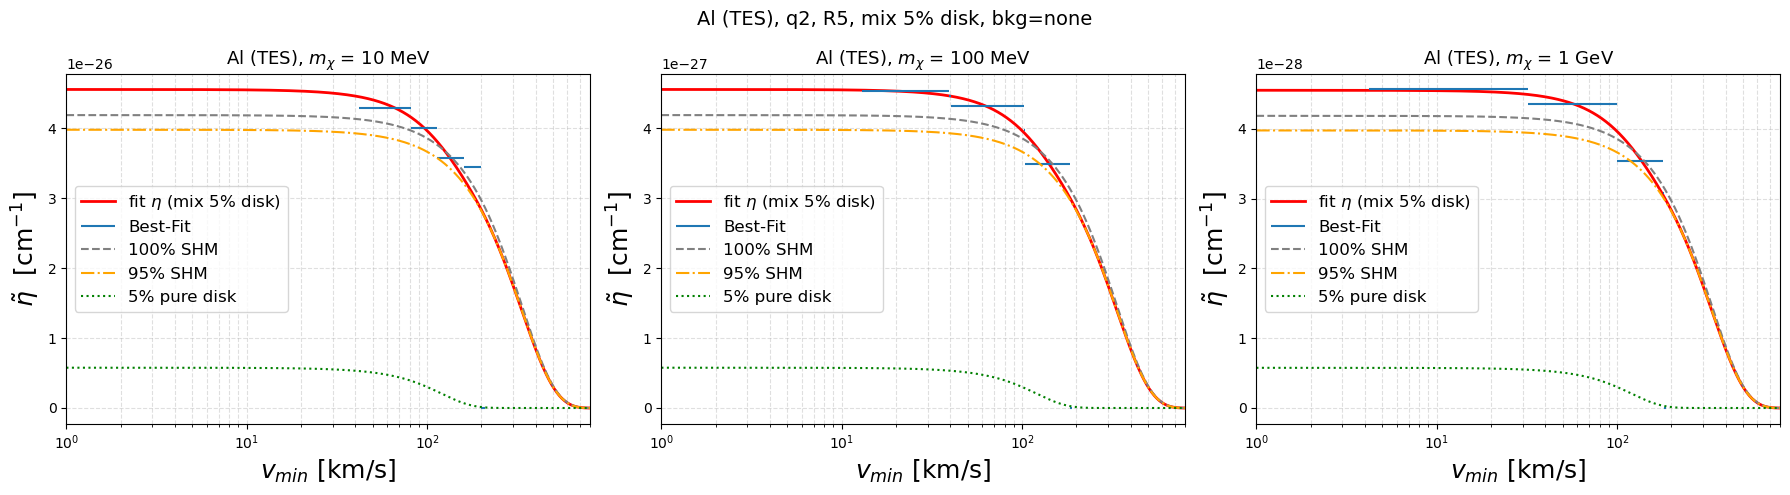

signal     : [1778.86572037 3031.88844603 3846.59526576 4332.96734451 4659.49279064]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q2_M1_R5_mix25/flux.pdf
Al q2 M1 R5: 5 E-bins x 210 v_min bins, peak flux 1.04e-30
signal     : [182.43250592 337.12781643 452.66602999 532.06870597 583.60749407]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q2_M2_R5_mix25/flux.pdf
Al q2 M2 R5: 5 E-bins x 219 v_min bins, peak flux 1.18e-31
signal     : [18.07244618 33.67594262 45.52279883 53.81238297 59.29128281]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q2_M3_R5_mix25/flux.pdf
Al q2 M3 R5: 5 E-bins x 227 v_min bins, peak flux 1.20e-32


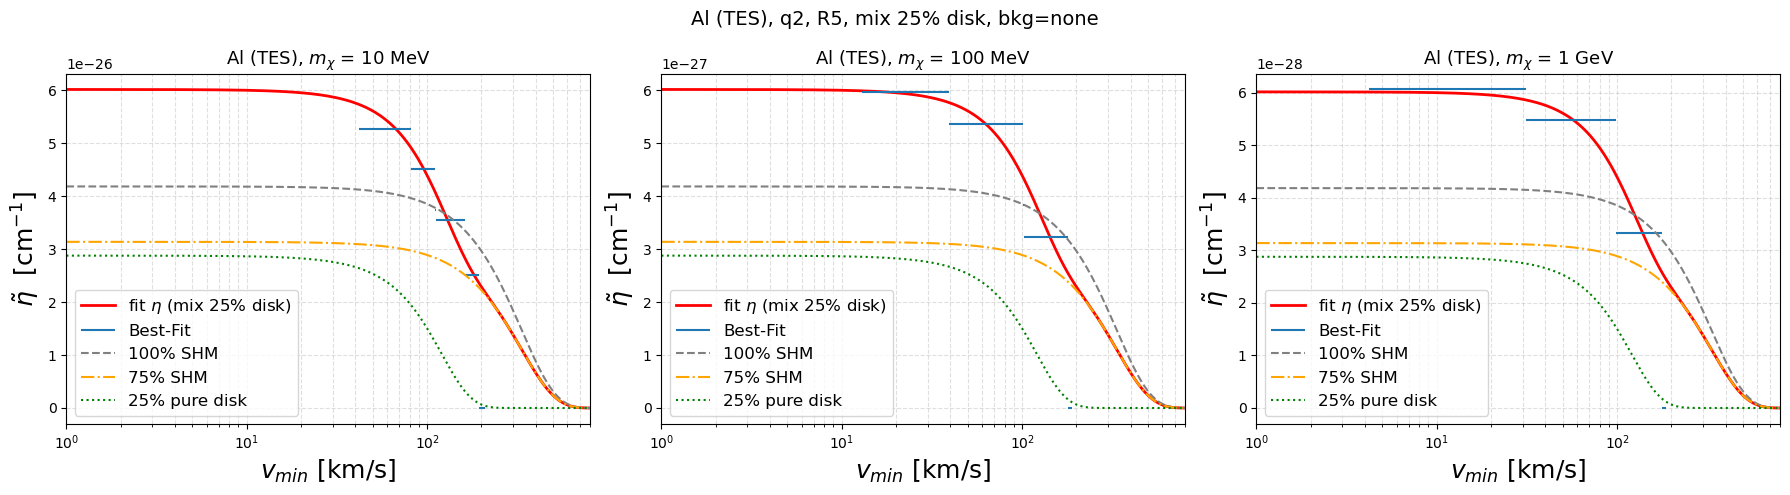

In [7]:
for p in DISK_FRACTIONS:
    run_masses('Al', q='2', nbins=5, disk_fraction=p)

### Heavy mediator (q0), 10 energy bins

signal     : [ 588.42938126  969.85097981 1333.11076627 1681.85241475 2019.72938531
 2321.92202173 2692.38304563 2953.64044167 3181.99939545 3497.37875982]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q0_M1_R10_mix5/flux.pdf
Al q0 M1 R10: 10 E-bins x 132 v_min bins, peak flux 8.40e-31
signal     : [ 67.09254983 100.23923427 137.32641497 180.48816961 218.60442929
 255.99604182 291.12543492 326.38303723 361.5075265  406.13294858]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q0_M2_R10_mix5/flux.pdf
Al q0 M2 R10: 10 E-bins x 66 v_min bins, peak flux 8.98e-32
signal     : [ 5.8858162  10.60103363 13.80673585 18.04889859 22.18756218 25.17885966
 29.2901919  33.33725177 36.24800935 40.28114846]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/Quan

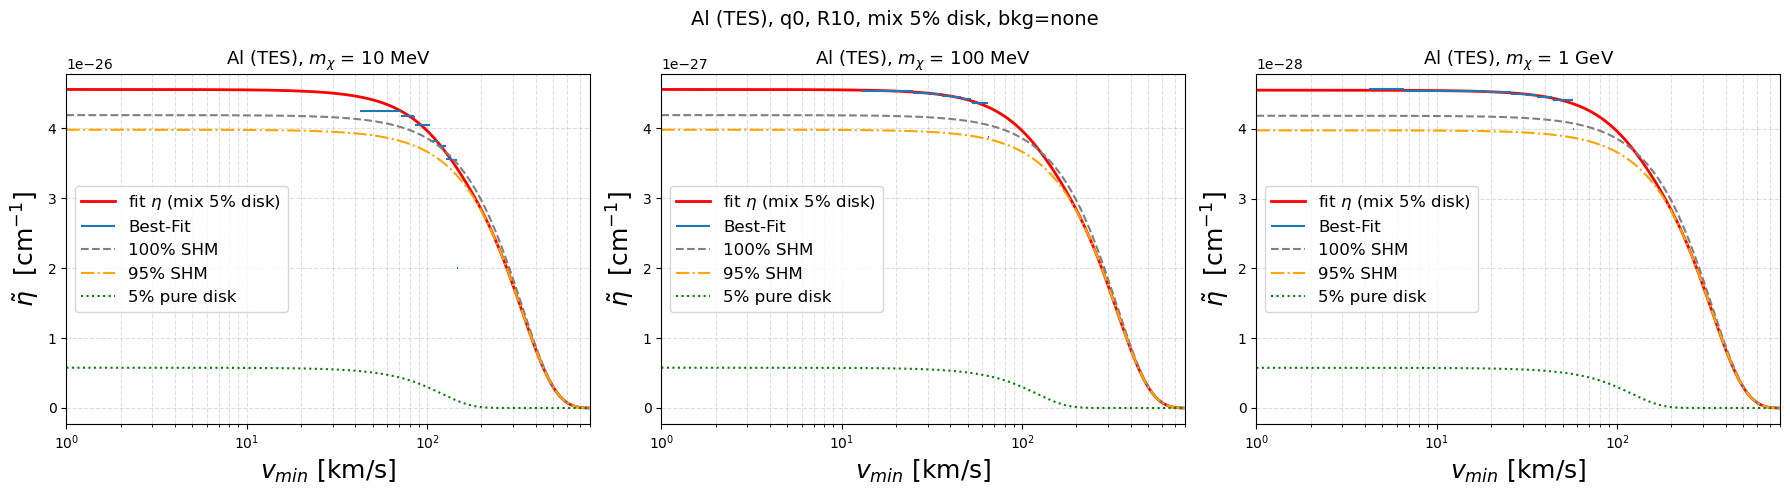

signal     : [ 688.67212839 1113.43559823 1495.54851049 1840.32196217 2153.41060781
 2410.36212911 2718.42145368 2905.79363096 3053.98339499 3276.39412202]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q0_M1_R10_mix25/flux.pdf
Al q0 M1 R10: 10 E-bins x 132 v_min bins, peak flux 1.03e-30
signal     : [ 88.36023607 131.66080507 179.75776092 235.28994743 283.73348056
 330.70466808 374.17701698 417.20610754 459.40888948 512.67154246]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q0_M2_R10_mix25/flux.pdf
Al q0 M2 R10: 10 E-bins x 66 v_min bins, peak flux 1.18e-31
signal     : [ 7.77588959 13.99204316 18.20196831 23.7529774  29.13494812 32.98711505
 38.25324258 43.37900285 46.99752799 51.97903611]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/Qu

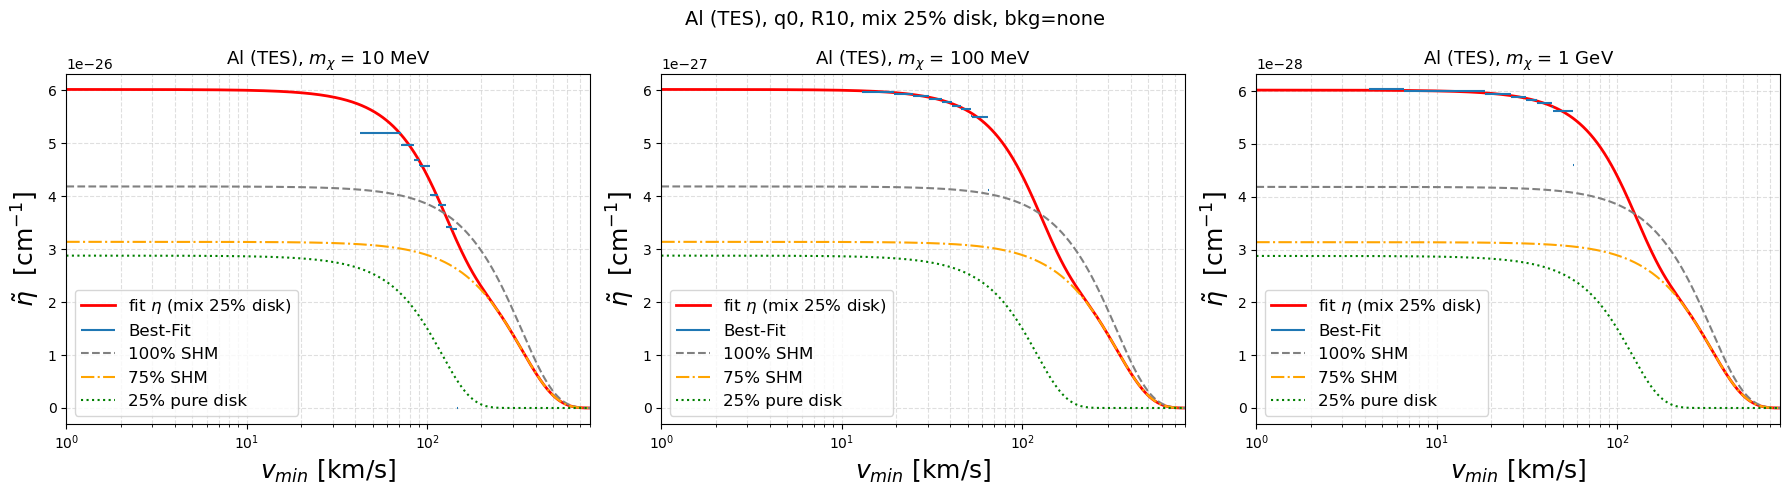

In [8]:
for p in DISK_FRACTIONS:
    run_masses('Al', q='0', nbins=10, disk_fraction=p, solver = 'scipy')

### Light mediator (q2), 10 energy bins

signal     : [ 574.89451663  949.82197652 1255.86183315 1544.07493072 1803.91567588
 2034.56630572 2251.37516757 2441.0542111  2605.10514466 2785.88114265]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q2_M1_R10_mix5/flux.pdf
Al q2 M1 R10: 10 E-bins x 220 v_min bins, peak flux 8.61e-31
signal     : [ 54.49316234  91.27670674 123.69323561 153.93276799 182.25674032
 208.28163243 232.23283524 252.88132509 272.9810765  291.29227884]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q2_M2_R10_mix5/flux.pdf
Al q2 M2 R10: 10 E-bins x 229 v_min bins, peak flux 8.95e-32
signal     : [ 5.43047372  9.03625907 12.26669976 15.38311686 18.14439393 20.84941933
 23.18660616 25.35786072 27.3944343  29.18264612]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/Qua

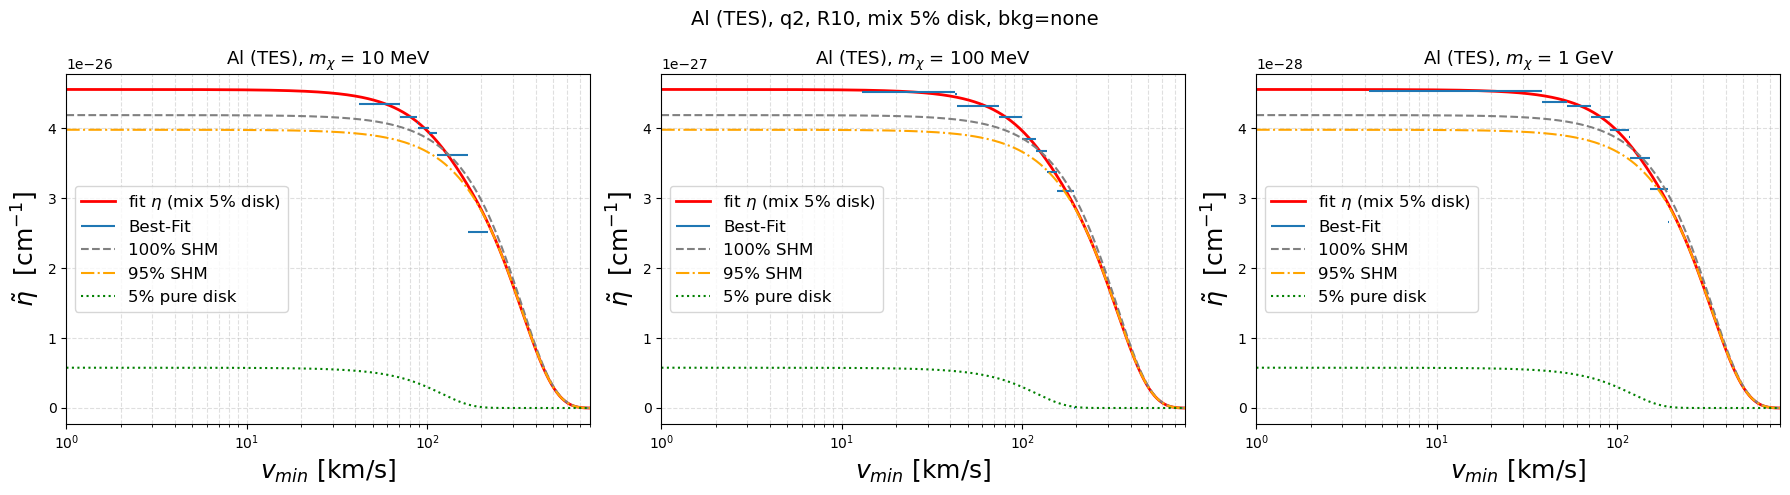

signal     : [ 721.79402807 1150.98313418 1462.99915013 1725.57265739 1933.3927401
 2090.4502044  2221.29932165 2321.16181841 2395.71139584 2492.32435873]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q2_M1_R10_mix25/flux.pdf
Al q2 M1 R10: 10 E-bins x 220 v_min bins, peak flux 1.08e-30
signal     : [ 71.53800679 118.67959204 158.55727198 193.6657393  224.04851031
 249.434258   270.28998724 286.11222646 299.98816249 311.17235831]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q2_M2_R10_mix25/flux.pdf
Al q2 M2 R10: 10 E-bins x 229 v_min bins, peak flux 1.18e-31
signal     : [ 7.14317671 11.79028443 15.80328673 19.47299318 22.49232871 25.20241432
 27.29884264 29.04071091 30.50867744 31.64267751]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/Qu

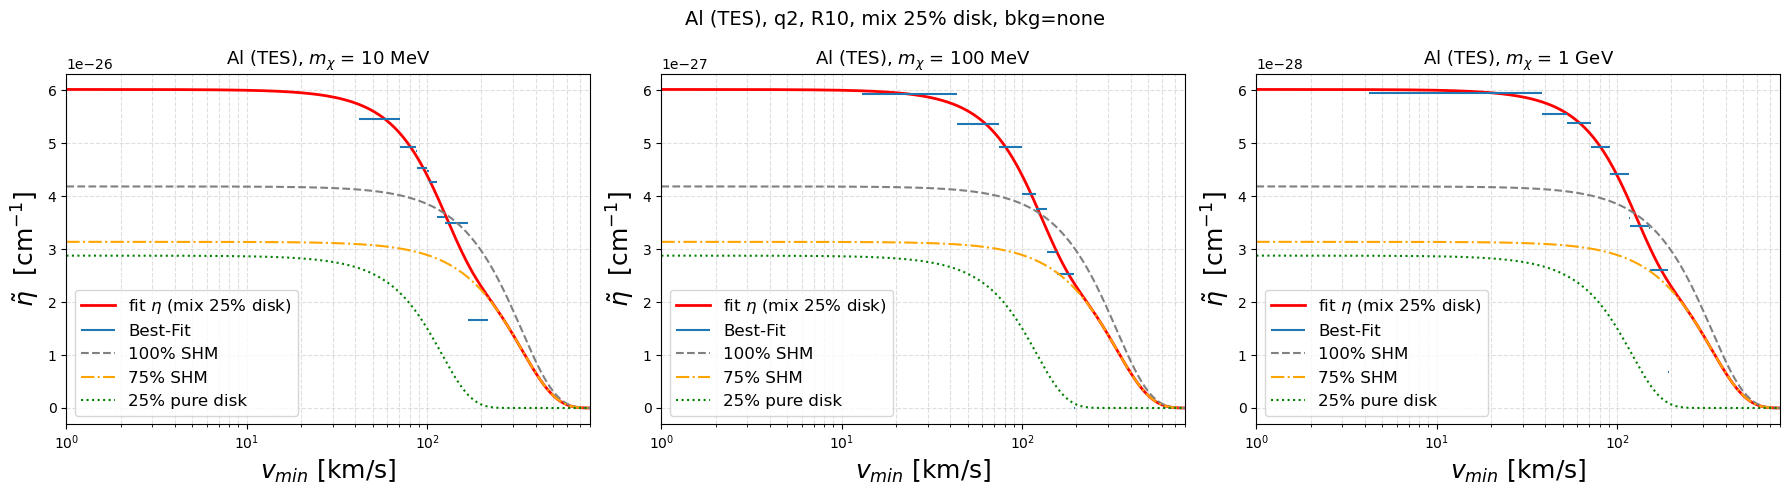

In [9]:
for p in DISK_FRACTIONS:
    run_masses('Al', q='2', nbins=10, disk_fraction=p)

## Bound (Earth-bound thermal DM)

Dense (`rho_b = 1e14` GeV/cm^3), isotropic, cold (`v0 ~ 2.16` km/s at 1 GeV), `vesc = 11.2` km/s. Only **M3 (1 GeV)** is shown: the bound population is too slow to reach the `v_min` thresholds of the lighter masses (M1/M2 have no signal).

### Heavy mediator (q0), 5 energy bins

signal     : [2.36412745e+14 2.38842861e+11 1.43354693e+08 2.07042838e+04
 6.80078440e+01]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q0_M3_R5_Bound/flux.pdf
Al q0 M3 R5: 5 E-bins x 64 v_min bins, peak flux 6.30e-19


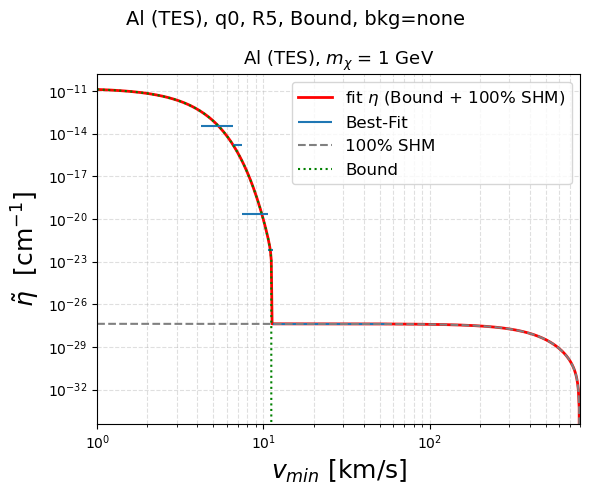

In [33]:
run_masses('Al', q='0', nbins=5, eta='Bound', masses=('3',))

### Light mediator (q2), 5 energy bins

signal     : [2.01745002e+12 1.80023137e+08 6.40396578e+04 4.78136149e+01
 5.26242246e+01]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q2_M3_R5_Bound/flux.pdf
Al q2 M3 R5: 5 E-bins x 227 v_min bins, peak flux 2.40e-19


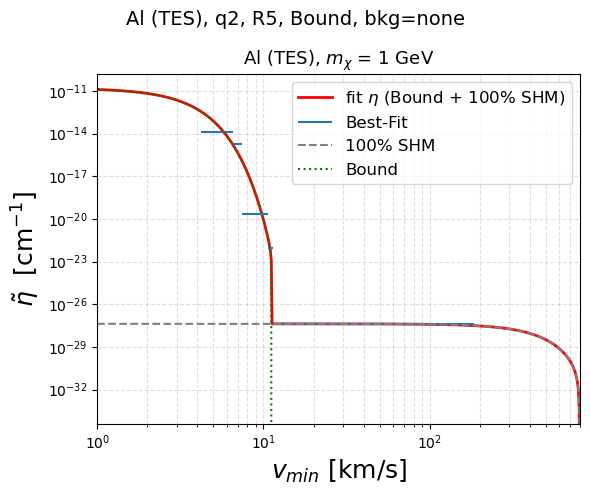

In [34]:
run_masses('Al', q='2', nbins=5, eta='Bound', masses=('3',))

### Heavy mediator (q0), 10 energy bins

signal     : [2.28806885e+14 9.73575431e+12 2.34242992e+11 6.25499599e+09
 1.41881739e+08 2.50622949e+06 2.06759468e+04 3.08268140e+01
 3.35606297e+01 3.73566765e+01]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q0_M3_R10_Bound/flux.pdf
Al q0 M3 R10: 10 E-bins x 67 v_min bins, peak flux 1.39e-18


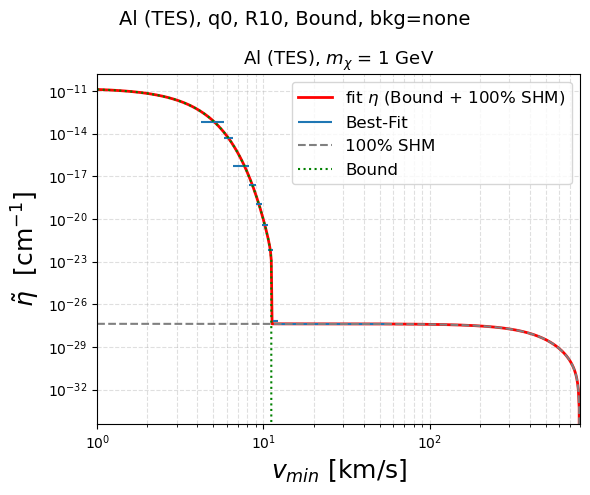

In [35]:
run_masses('Al', q='0', nbins=10, eta='Bound', masses=('3',))

### Light mediator (q2), 10 energy bins

signal     : [2.00747570e+12 1.37129880e+10 1.78148200e+08 2.70657510e+06
 6.37384654e+04 6.30383100e+02 2.54838593e+01 2.44371482e+01
 2.66158735e+01 2.85676383e+01]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q2_M3_R10_Bound/flux.pdf
Al q2 M3 R10: 10 E-bins x 237 v_min bins, peak flux 1.05e-18


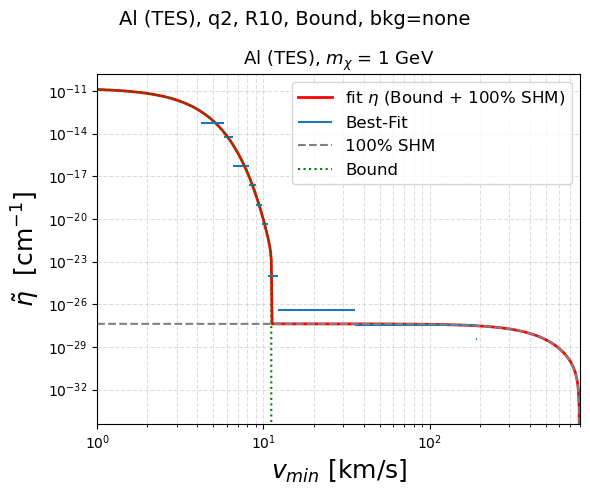

In [36]:
run_masses('Al', q='2', nbins=10, eta='Bound', masses=('3',))

## With a background scenario (Halo)

signal     : [1412.52911899 2819.10531101 4114.88291643 5395.20086016 6519.33435773]
background : [40.21562004 39.56384709 38.92498011 38.29876355 37.68494691]
Al q0 M1 R5: 5 E-bins x 130 v_min bins, peak flux 7.83e-31
signal     : [148.72936743 286.12914202 428.01488718 561.3399321  688.91644664]
background : [40.21562004 39.56384709 38.92498011 38.29876355 37.68494691]
Al q0 M2 R5: 5 E-bins x 63 v_min bins, peak flux 8.26e-32
signal     : [14.57845243 27.38823471 42.52742334 55.38644181 68.00784404]
background : [40.21562004 39.56384709 38.92498011 38.29876355 37.68494691]
Al q0 M3 R5: 5 E-bins x 64 v_min bins, peak flux 8.30e-33


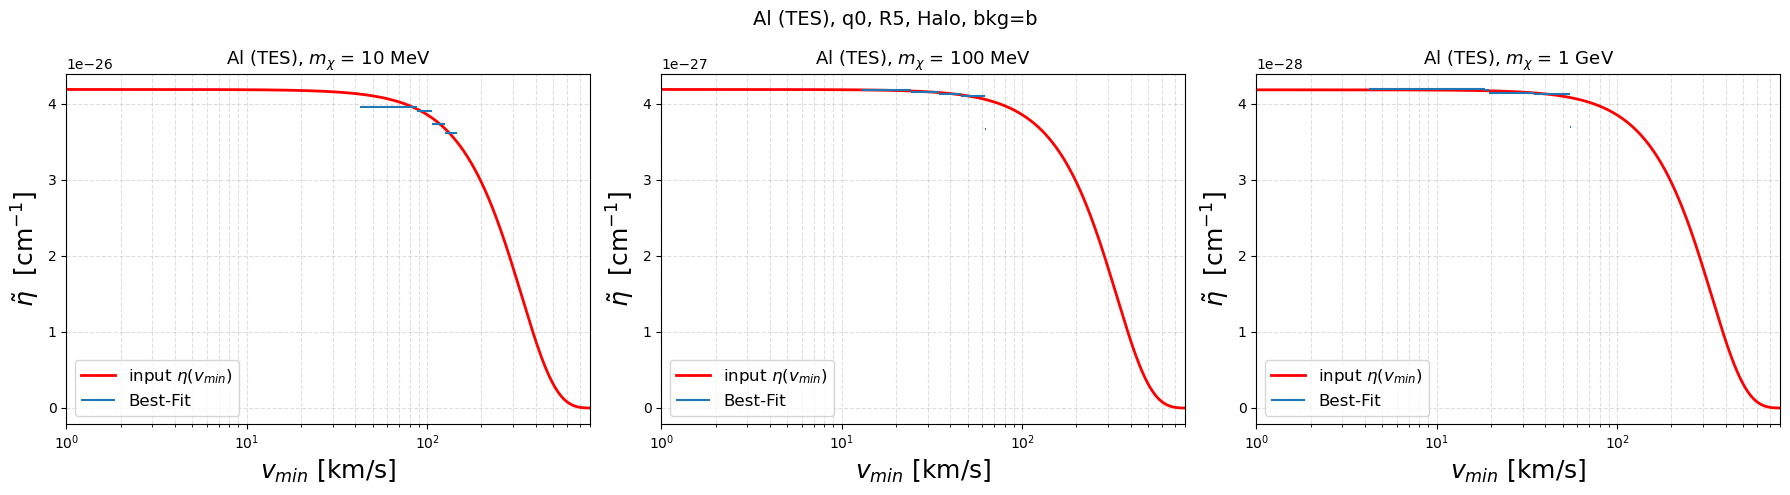

In [14]:
run_masses('Al', q='0', nbins=5, eta='Halo', background='b', solver = 'scipy', save = False)

signal     : [1362.03322362 2563.95126029 3621.13872896 4509.97437384 5257.42449272]
background : [40.21562004 39.56384709 38.92498011 38.29876355 37.68494691]
Al q2 M1 R5: 5 E-bins x 210 v_min bins, peak flux 8.00e-31
signal     : [128.99687548 247.60323028 353.30862736 446.90441419 527.6480368 ]
background : [40.21562004 39.56384709 38.92498011 38.29876355 37.68494691]
Al q2 M2 R5: 5 E-bins x 219 v_min bins, peak flux 8.26e-32
signal     : [12.72943263 24.53959016 35.10107731 44.48830266 52.62422455]
background : [40.21562004 39.56384709 38.92498011 38.29876355 37.68494691]
Al q2 M3 R5: 5 E-bins x 227 v_min bins, peak flux 8.30e-33


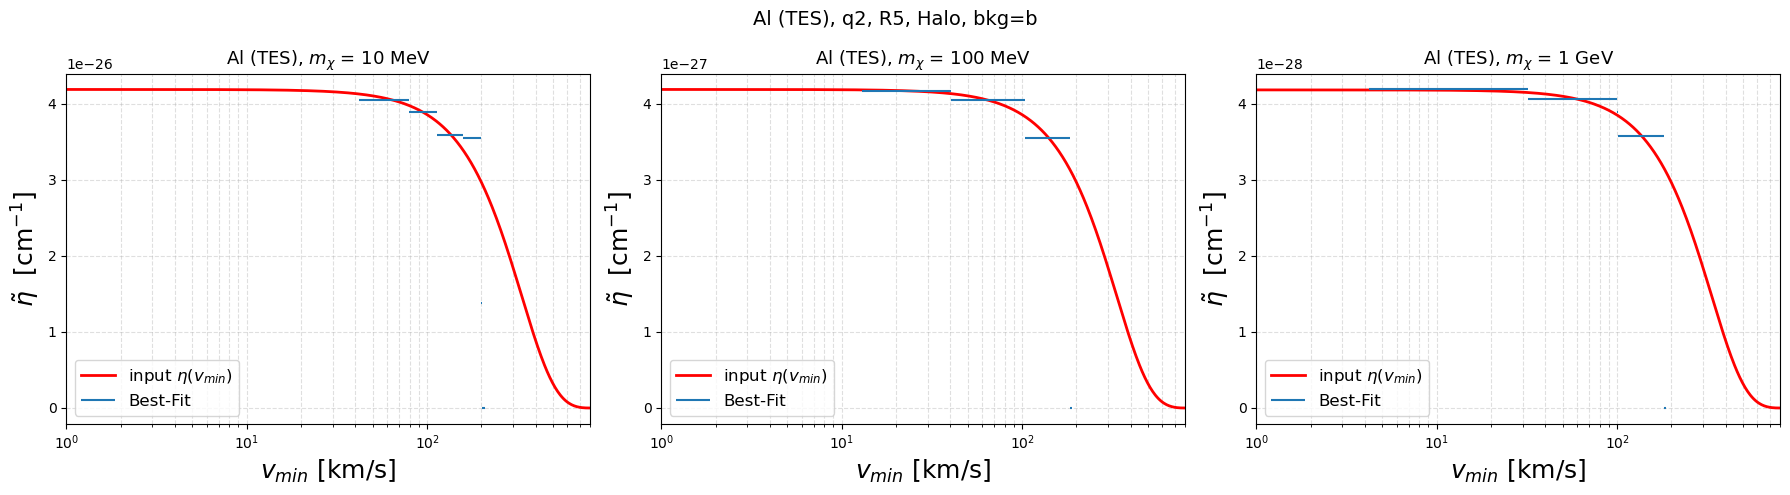

In [15]:
run_masses('Al', q='2', nbins=5, eta='Halo', background='b', save = False)

signal     : [1412.52911899 2819.10531101 4114.88291643 5395.20086016 6519.33435773]
background : [5.03778479 4.9669399  4.89749784 4.82943082 4.76271162]
Al q0 M1 R5: 5 E-bins x 130 v_min bins, peak flux 7.83e-31
signal     : [148.72936743 286.12914202 428.01488718 561.3399321  688.91644664]
background : [5.03778479 4.9669399  4.89749784 4.82943082 4.76271162]
Al q0 M2 R5: 5 E-bins x 63 v_min bins, peak flux 8.26e-32
signal     : [14.57845243 27.38823471 42.52742334 55.38644181 68.00784404]
background : [5.03778479 4.9669399  4.89749784 4.82943082 4.76271162]
Al q0 M3 R5: 5 E-bins x 64 v_min bins, peak flux 8.29e-33


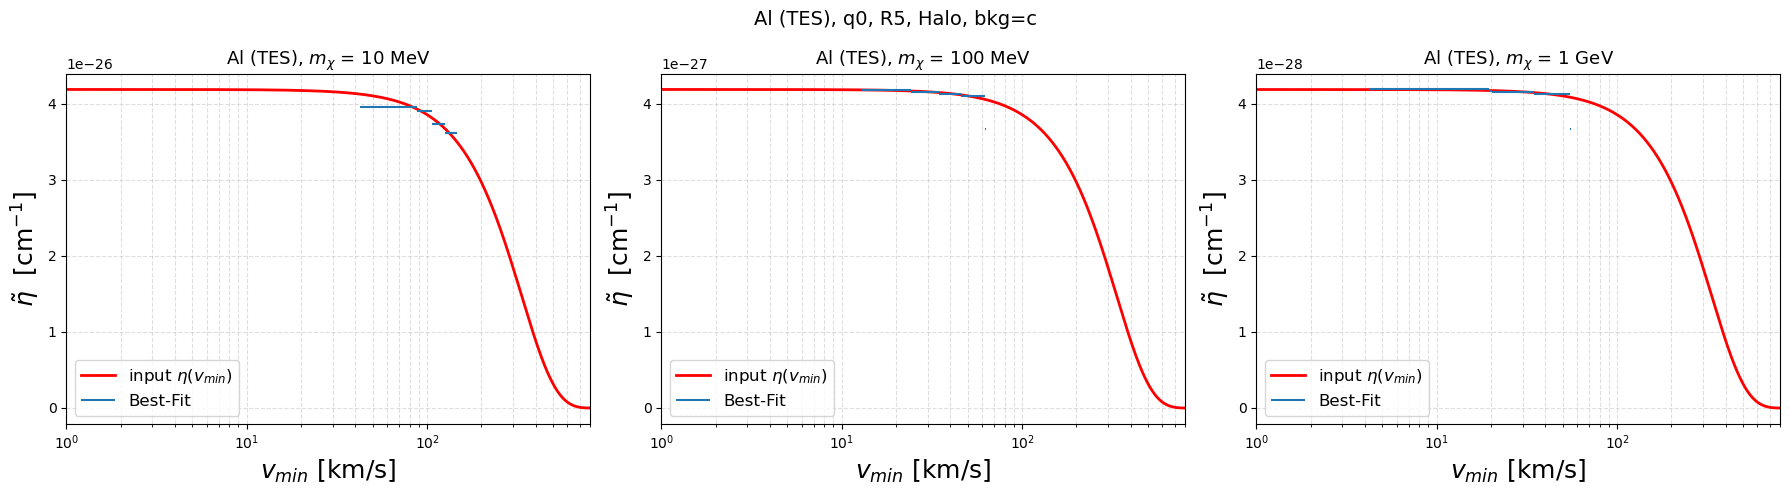

In [16]:
run_masses('Al', q='0', nbins=5, eta='Halo', background='c', solver = 'scipy', save = False)

signal     : [1362.03322362 2563.95126029 3621.13872896 4509.97437384 5257.42449272]
background : [5.03778479 4.9669399  4.89749784 4.82943082 4.76271162]
Al q2 M1 R5: 5 E-bins x 210 v_min bins, peak flux 8.00e-31
signal     : [128.99687548 247.60323028 353.30862736 446.90441419 527.6480368 ]
background : [5.03778479 4.9669399  4.89749784 4.82943082 4.76271162]
Al q2 M2 R5: 5 E-bins x 219 v_min bins, peak flux 8.26e-32
signal     : [12.72943263 24.53959016 35.10107731 44.48830266 52.62422455]
background : [5.03778479 4.9669399  4.89749784 4.82943082 4.76271162]
Al q2 M3 R5: 5 E-bins x 227 v_min bins, peak flux 8.30e-33


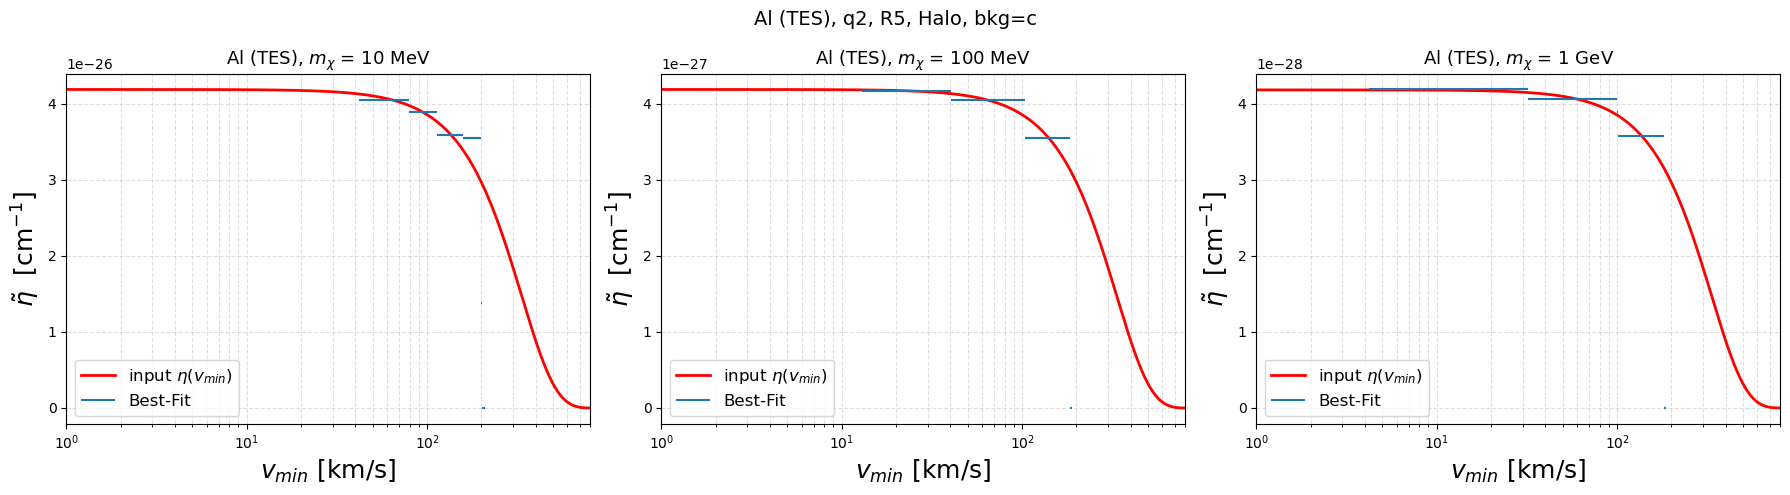

In [17]:
run_masses('Al', q='2', nbins=5, eta='Halo', background='c', save = False)

# MKID (TiN)

Titanium-nitride detector, Lindhard dielectric. Threshold **0.2 eV** (bins start at 0.2 eV, fine binning **`R9`**). Heavy mediator (`q0`) only so far.

## Halo (SHM) — reference

### Heavy mediator (q0), 5 energy bins

signal     : [ 894.65138334 2487.54875376 3618.56702333 4809.95397413 5675.30384356]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q0_M1_R5_Halo/flux.pdf
TiN q0 M1 R5: 5 E-bins x 114 v_min bins, peak flux 7.96e-31
signal     : [ 82.39153174 249.06083045 355.91522766 464.82484493 576.83053664]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q0_M2_R5_Halo/flux.pdf
TiN q0 M2 R5: 5 E-bins x 109 v_min bins, peak flux 8.24e-32
signal     : [ 7.84341547 24.17121096 35.8367542  46.70293506 56.84328262]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q0_M3_R5_Halo/flux.pdf
TiN q0 M3 R5: 5 E-bins x 118 v_min bins, peak flux 8.26e-33


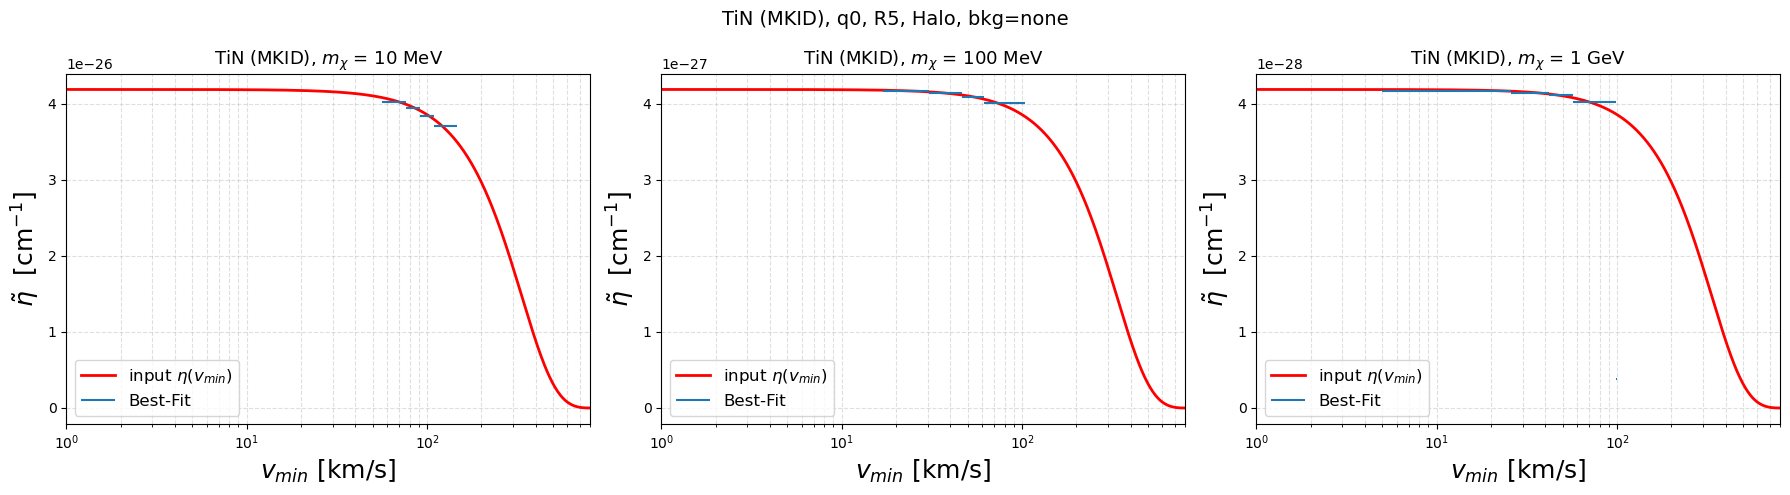

In [18]:
run_masses('TiN', q='0', nbins=5, eta='Halo', solver = 'scipy')

### Light mediator (q2), 5 energy bins

signal     : [ 7283.62415055 19851.85889154 26075.30319157 30374.36111277
 33233.39714365]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q2_M1_R5_Halo/flux.pdf
TiN q2 M1 R5: 5 E-bins x 276 v_min bins, peak flux 7.94e-31
signal     : [ 681.04295936 1883.88296992 2508.32722647 2975.7466291  3303.37218639]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q2_M2_R5_Halo/flux.pdf
TiN q2 M2 R5: 5 E-bins x 305 v_min bins, peak flux 8.39e-32
signal     : [ 67.69182947 186.93137579 249.41929983 296.45569808 329.68548871]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q2_M3_R5_Halo/flux.pdf
TiN q2 M3 R5: 5 E-bins x 318 v_min bins, peak flux 8.42e-33


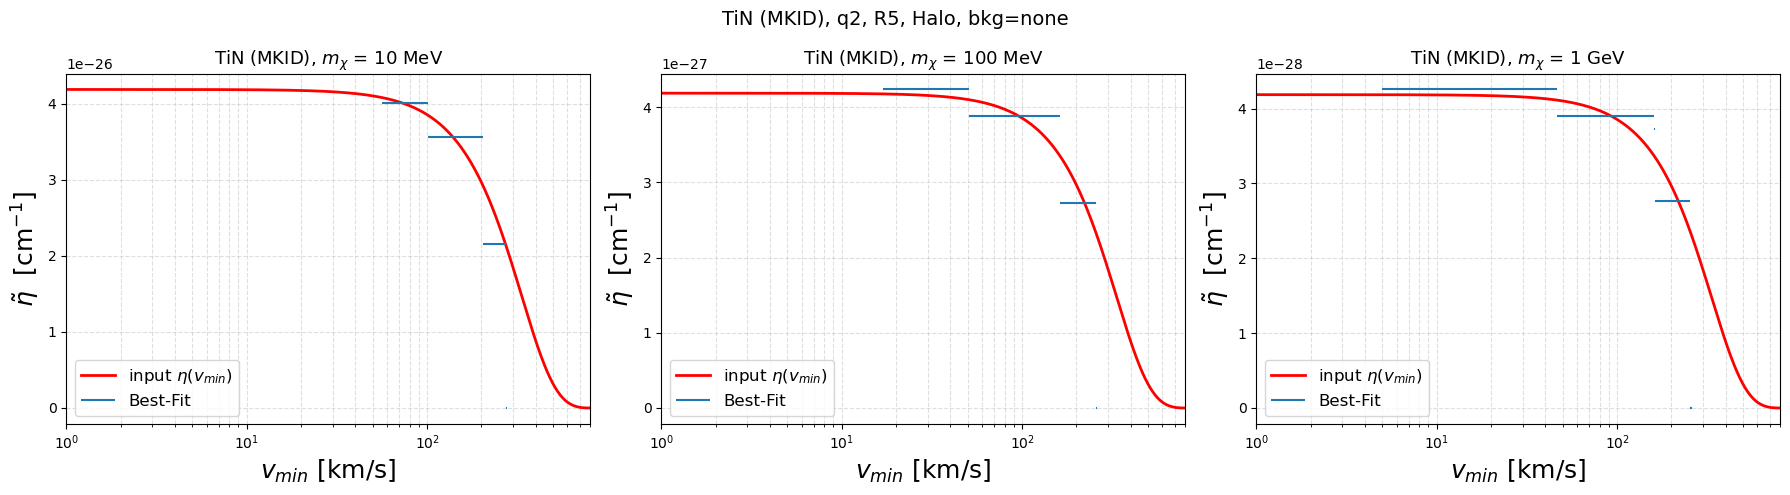

In [19]:
run_masses('TiN', q='2', nbins=5, eta='Halo')

### Heavy mediator (q0), 9 energy bins

signal     : [ 894.65138334 1149.64586739 1477.15155664 1813.952521   2111.6798815
 2420.08888112 2586.66798747 2854.36417147 3101.49222263]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q0_M1_R9_Halo/flux.pdf
TiN q0 M1 R9: 9 E-bins x 119 v_min bins, peak flux 7.96e-31
signal     : [ 82.39153174 113.84223886 143.98542769 173.15835051 201.51890167
 229.13488825 261.91926419 287.81272209 312.75362816]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q0_M2_R9_Halo/flux.pdf
TiN q0 M2 R9: 9 E-bins x 114 v_min bins, peak flux 8.24e-32
signal     : [ 7.84341547 10.92909607 13.91816581 17.40229747 20.24176142 23.0105825
 25.70658107 28.31486791 31.38283182]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/

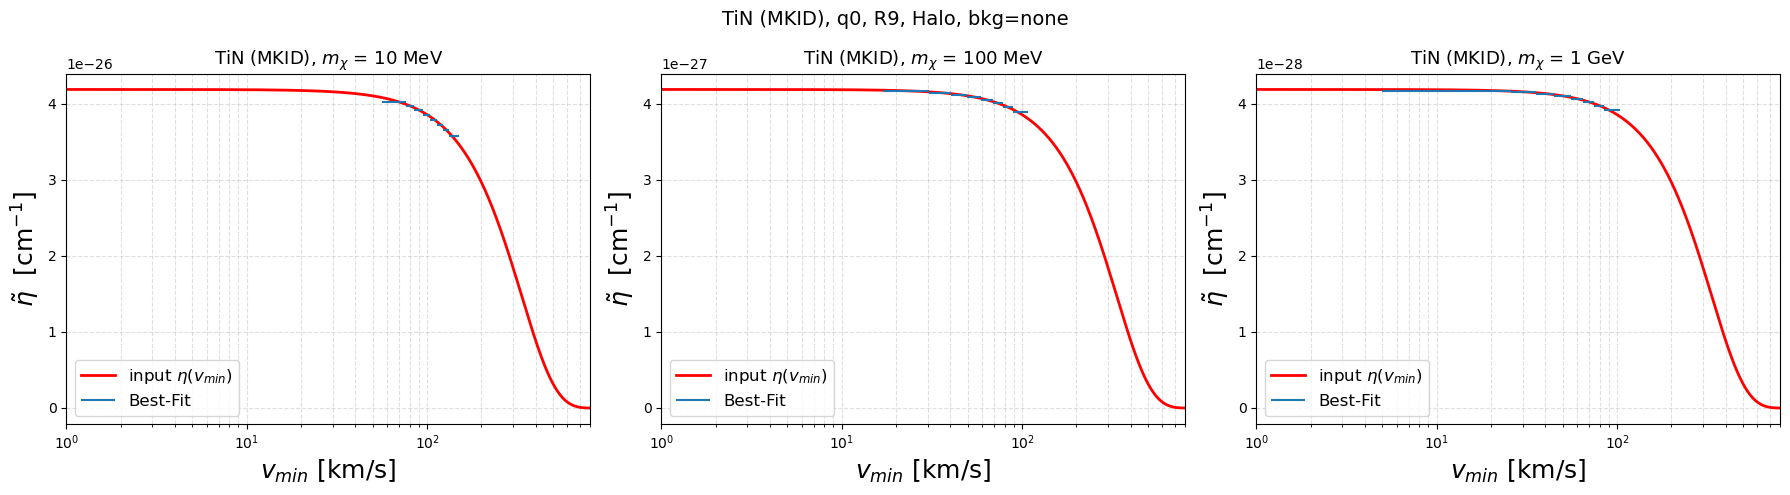

In [20]:
run_masses('TiN', q='0', nbins=9, eta='Halo')

### Light mediator (q2), 9 energy bins

## Mixture (best-fit) — sweep dark-disk fraction

`eta = (1-p)*Halo + p*Disk`. Each figure overlays 100% SHM (gray) and `p` x pure disk (green).

### Heavy mediator (q0), 5 energy bins

signal     : [ 946.84827889 2599.34471401 3709.36119002 4836.01170446 5610.57442522]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q0_M1_R5_mix5/flux.pdf
TiN q0 M1 R5: 5 E-bins x 114 v_min bins, peak flux 8.42e-31
signal     : [ 89.31040697 268.85337923 380.99820316 491.61970156 600.72852715]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q0_M2_R5_mix5/flux.pdf
TiN q0 M2 R5: 5 E-bins x 109 v_min bins, peak flux 8.93e-32
signal     : [ 8.51199364 26.14118986 38.46909534 49.58534438 59.49781982]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q0_M3_R5_mix5/flux.pdf
TiN q0 M3 R5: 5 E-bins x 118 v_min bins, peak flux 8.96e-33


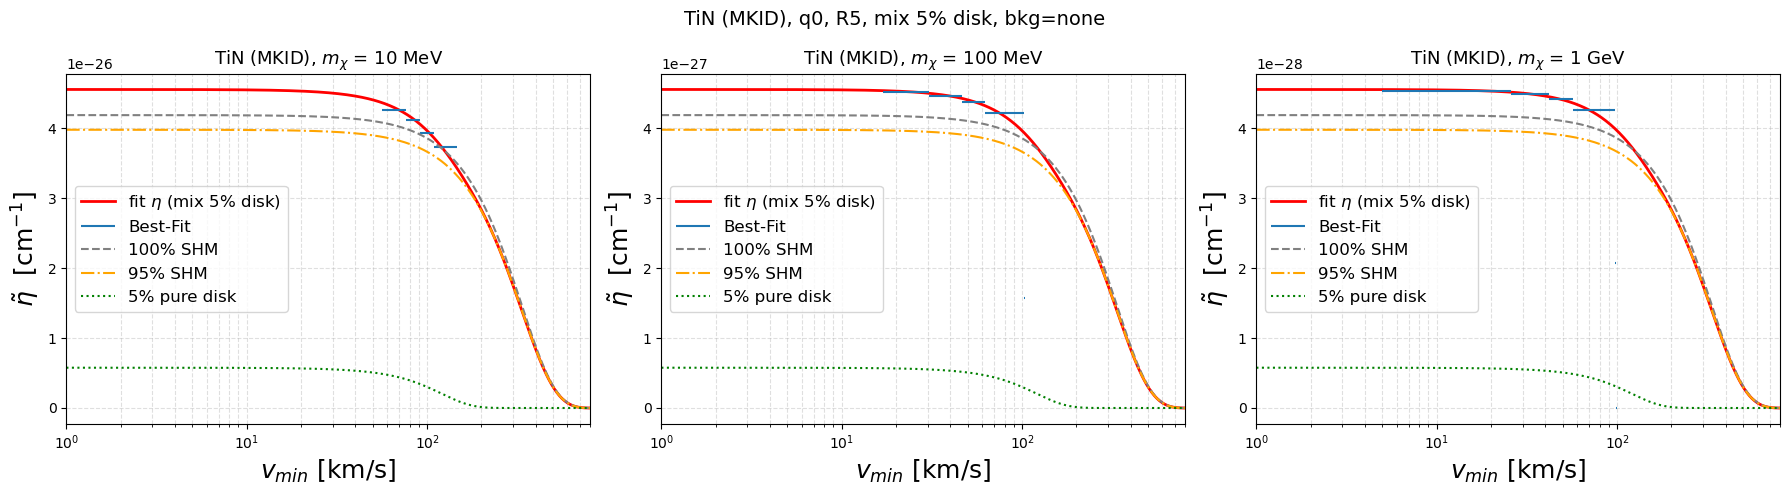

signal     : [1155.63586111 3046.52855501 4072.53785679 4940.24262577 5351.65675185]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q0_M1_R5_mix25/flux.pdf
TiN q0 M1 R5: 5 E-bins x 114 v_min bins, peak flux 1.03e-30
signal     : [116.98590791 348.02357435 481.33010517 598.79912806 696.32048921]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q0_M2_R5_mix25/flux.pdf
TiN q0 M2 R5: 5 E-bins x 109 v_min bins, peak flux 1.17e-31
signal     : [11.18630633 34.02110547 48.99845988 61.11498163 70.11596863]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q0_M3_R5_mix25/flux.pdf
TiN q0 M3 R5: 5 E-bins x 118 v_min bins, peak flux 1.18e-32


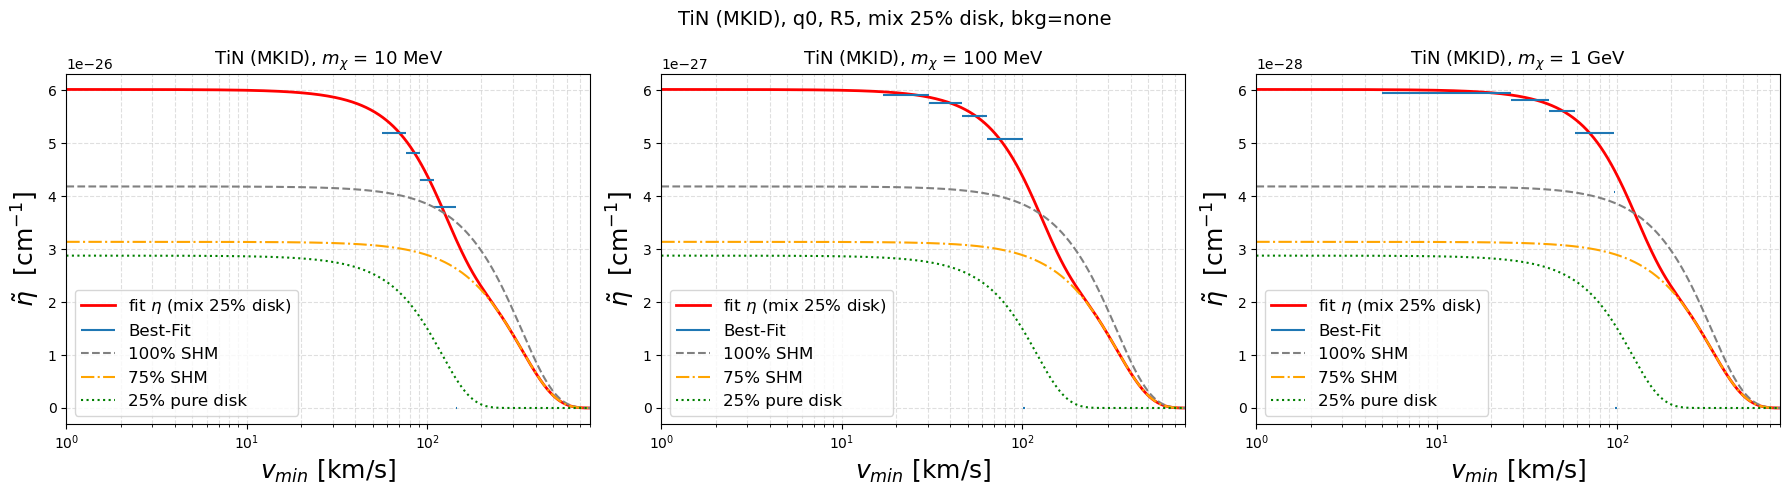

In [21]:
for p in DISK_FRACTIONS:
    run_masses('TiN', q='0', nbins=5, disk_fraction=p)

### Light mediator (q2), 5 energy bins

signal     : [ 7661.99203087 20386.27786043 26048.71619823 29750.68588513
 32138.43983561]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q2_M1_R5_mix5/flux.pdf
TiN q2 M1 R5: 5 E-bins x 276 v_min bins, peak flux 8.40e-31
signal     : [ 729.18354882 1981.80691138 2577.15442432 2995.71901203 3272.1909663 ]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q2_M2_R5_mix5/flux.pdf
TiN q2 M2 R5: 5 E-bins x 305 v_min bins, peak flux 9.18e-32
signal     : [ 72.55762885 197.02887054 256.90164615 299.25285779 327.44185854]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q2_M3_R5_mix5/flux.pdf
TiN q2 M3 R5: 5 E-bins x 318 v_min bins, peak flux 9.25e-33


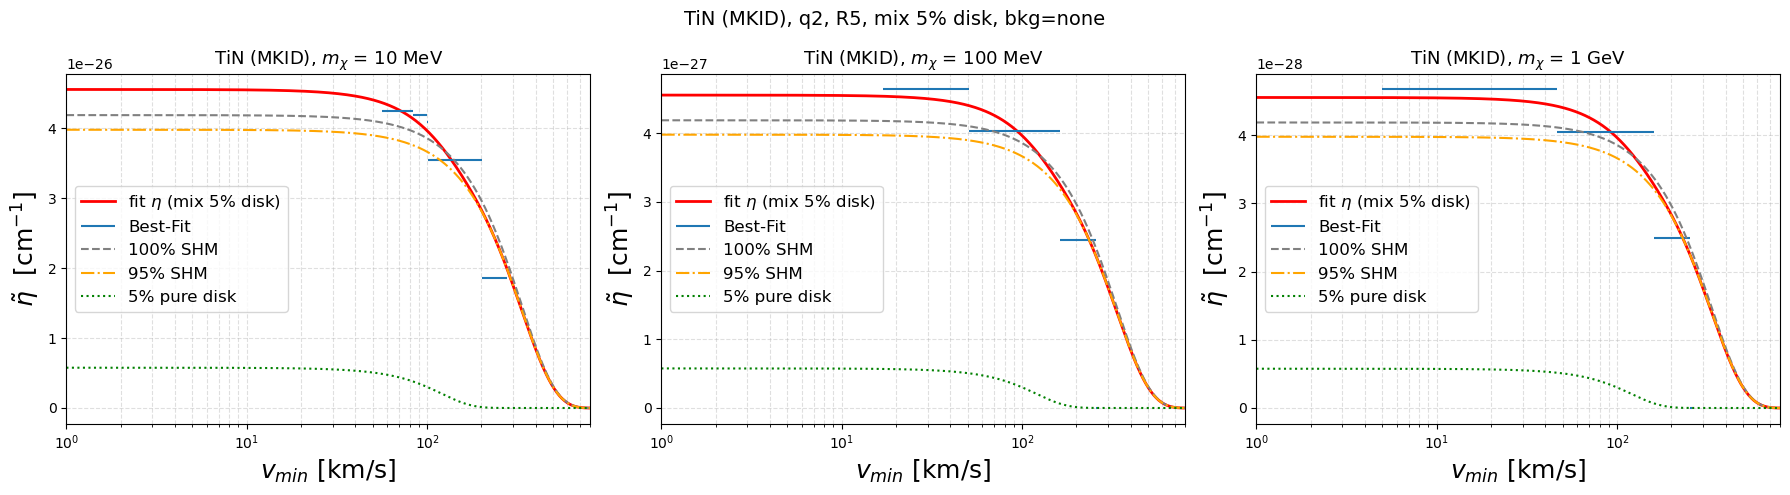

signal     : [ 9175.46355211 22523.95373597 25942.36822484 27255.98497458
 27758.61060346]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q2_M1_R5_mix25/flux.pdf
TiN q2 M1 R5: 5 E-bins x 276 v_min bins, peak flux 1.02e-30
signal     : [ 921.74590666 2373.50267724 2852.46321574 3075.60854373 3147.46608593]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q2_M2_R5_mix25/flux.pdf
TiN q2 M2 R5: 5 E-bins x 305 v_min bins, peak flux 1.23e-31
signal     : [ 92.02082639 237.41884956 286.83103139 310.44149662 318.46733787]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q2_M3_R5_mix25/flux.pdf
TiN q2 M3 R5: 5 E-bins x 318 v_min bins, peak flux 1.25e-32


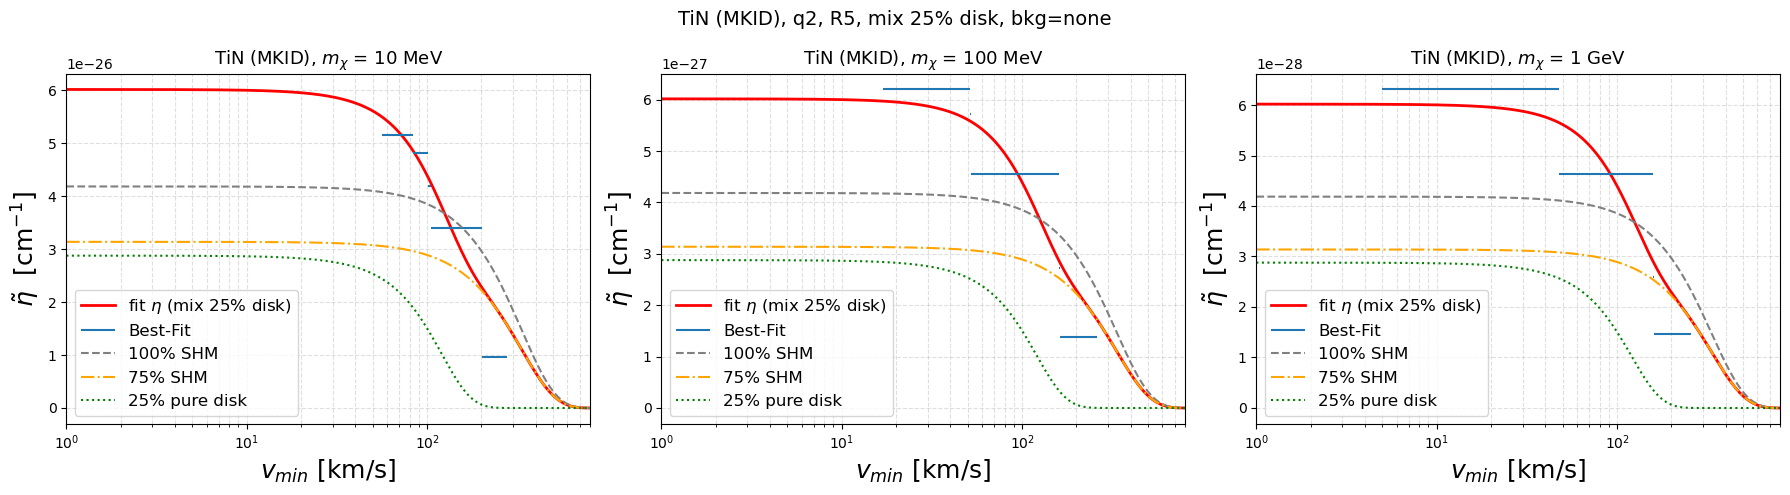

In [22]:
for p in DISK_FRACTIONS:
    run_masses('TiN', q='2', nbins=5, disk_fraction=p)

### Heavy mediator (q0), 9 energy bins

signal     : [ 946.84827889 1206.17948932 1534.98489802 1866.72649705 2152.00896883
 2442.82885828 2588.29818661 2831.92294505 3053.39516376]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q0_M1_R9_mix5/flux.pdf
TiN q0 M1 R9: 9 E-bins x 119 v_min bins, peak flux 8.42e-31
signal     : [ 89.31040697 123.08680278 155.15435813 185.80240717 215.1286462
 243.14428265 275.96076651 300.95059672 324.3758858 ]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q0_M2_R9_mix5/flux.pdf
TiN q0 M2 R9: 9 E-bins x 114 v_min bins, peak flux 8.93e-32
signal     : [ 8.51199364 11.83614647 15.03046579 18.72093147 21.67584382 24.50618958
 27.20438404 29.75200286 32.70993248]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none

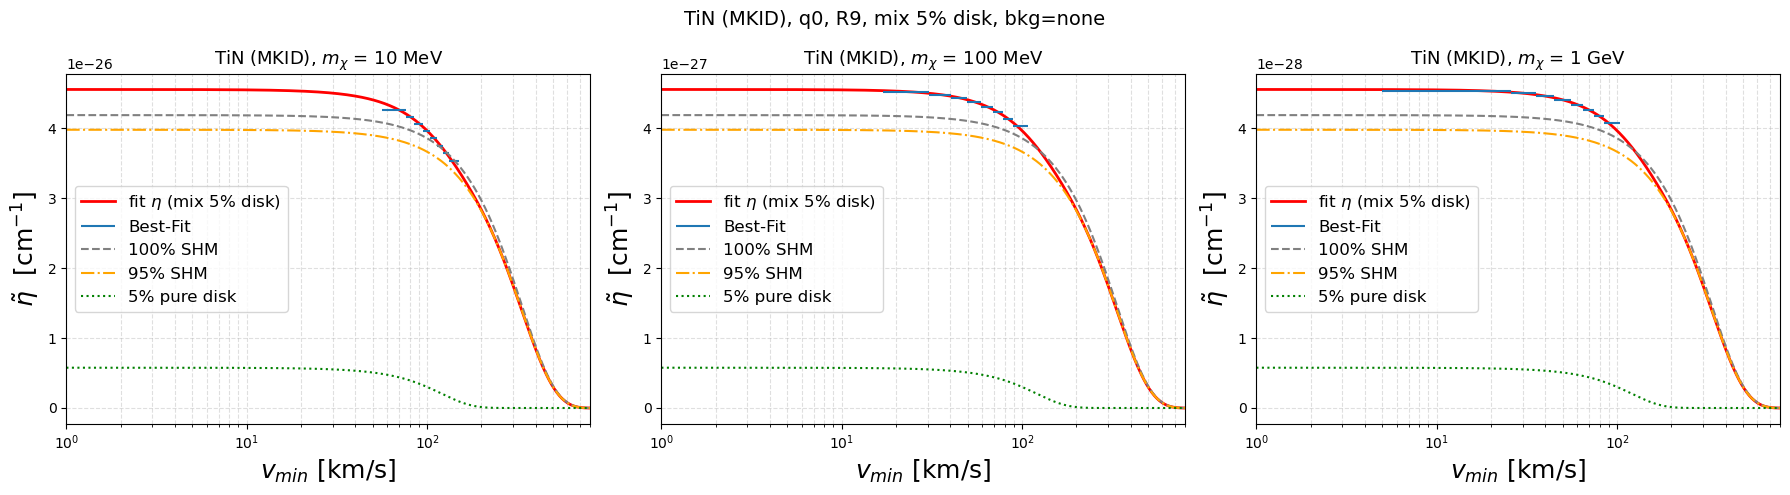

signal     : [1155.63586111 1432.31397702 1766.31826354 2077.82240125 2313.32531812
 2533.78876691 2594.8189832  2742.15803939 2861.00692827]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q0_M1_R9_mix25/flux.pdf
TiN q0 M1 R9: 9 E-bins x 119 v_min bins, peak flux 1.03e-30
signal     : [116.98590791 160.06505846 199.8300799  236.37863382 269.5676243
 299.18186024 332.1267758  353.50209524 370.86491636]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q0_M2_R9_mix25/flux.pdf
TiN q0 M2 R9: 9 E-bins x 114 v_min bins, peak flux 1.17e-31
signal     : [11.18630633 15.46434805 19.4796657  23.99546746 27.41217344 30.48861792
 33.19559593 35.50054264 38.01833513]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-no

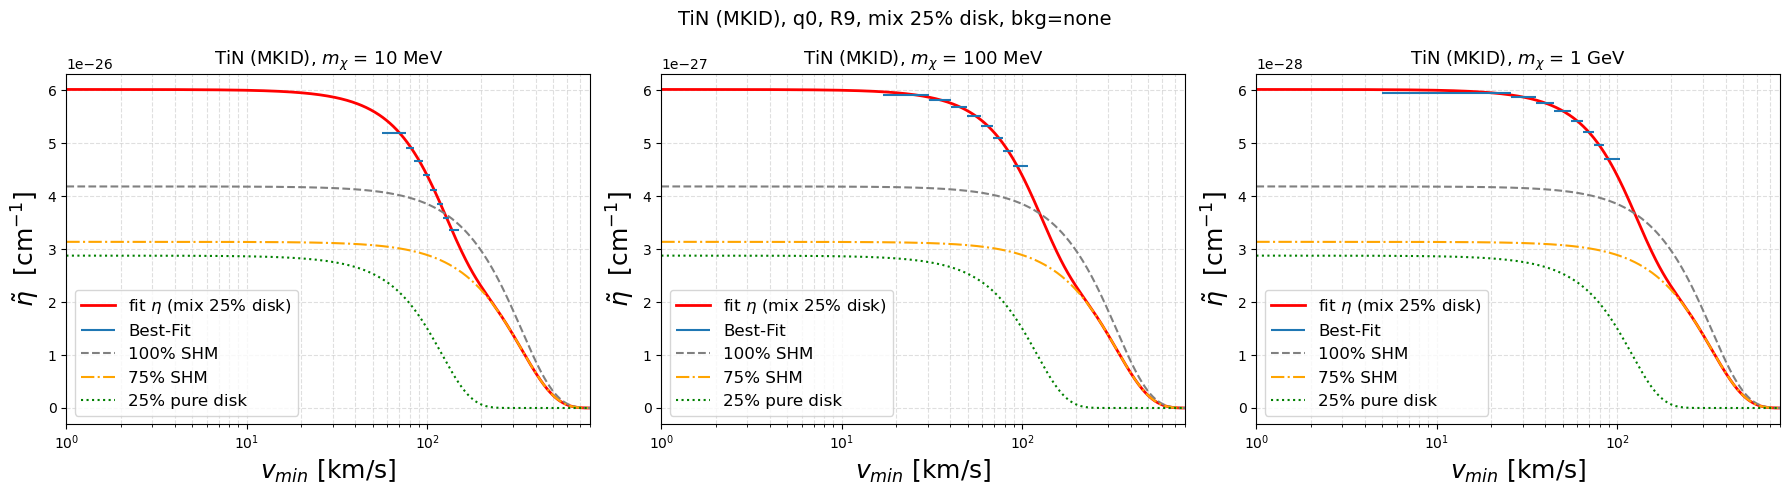

In [23]:
for p in DISK_FRACTIONS:
    run_masses('TiN', q='0', nbins=9, disk_fraction=p)

### Light mediator (q2), 9 energy bins

## Bound (Earth-bound thermal DM)

Dense (`rho_b = 1e14` GeV/cm^3), isotropic, cold (`v0 ~ 2.16` km/s at 1 GeV), `vesc = 11.2` km/s. Only **M3 (1 GeV)** is shown: the bound population is too slow to reach the `v_min` thresholds of the lighter masses (M1/M2 have no signal).

### Heavy mediator (q0), 5 energy bins

signal     : [6.55781085e+09 9.72961612e+07 3.17374602e+04 5.58776869e+01
 5.68432826e+01]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q0_M3_R5_Bound/flux.pdf
TiN q0 M3 R5: 5 E-bins x 118 v_min bins, peak flux 7.63e-20


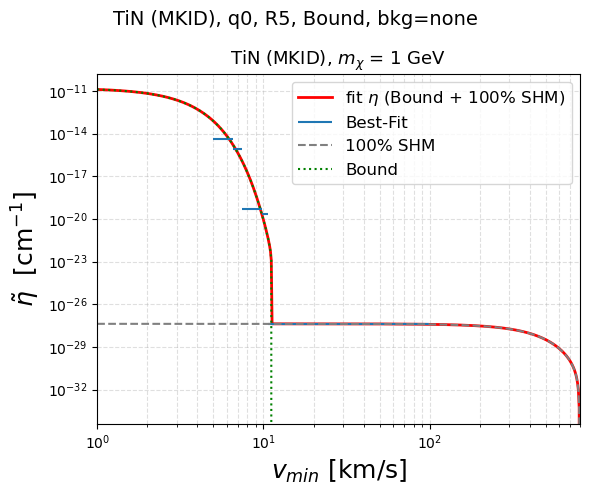

In [37]:
run_masses('TiN', q='0', nbins=5, eta='Bound', masses=('3',))

### Light mediator (q2), 5 energy bins

signal     : [3.15490389e+07 1.36069685e+05 2.61414292e+02 2.96457420e+02
 3.29685489e+02]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q2_M3_R5_Bound/flux.pdf
TiN q2 M3 R5: 5 E-bins x 318 v_min bins, peak flux 2.25e-20


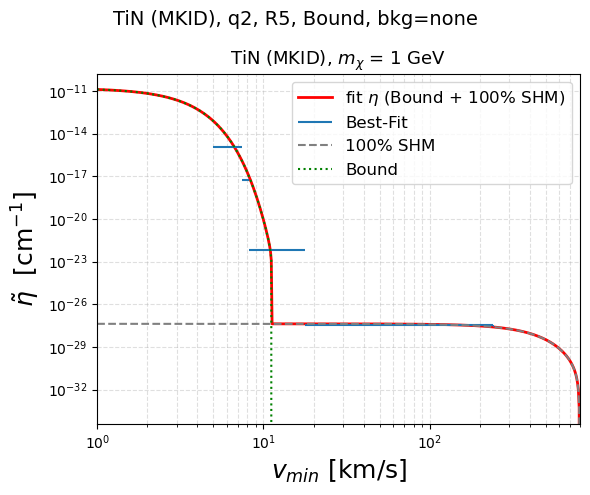

In [38]:
run_masses('TiN', q='2', nbins=5, eta='Bound', masses=('3',))

### Heavy mediator (q0), 9 energy bins

signal     : [6.55781085e+09 9.63103947e+07 1.51863816e+06 3.12910858e+04
 6.20832937e+02 3.21596028e+01 2.58047834e+01 2.83148679e+01
 3.13828318e+01]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q0_M3_R9_Bound/flux.pdf
TiN q0 M3 R9: 9 E-bins x 124 v_min bins, peak flux 8.14e-20


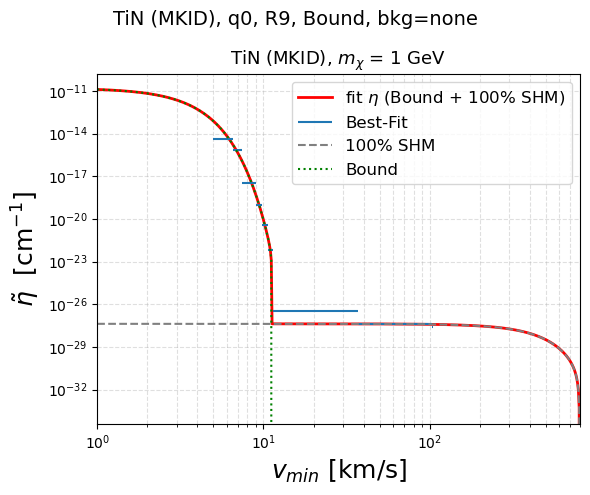

In [39]:
run_masses('TiN', q='0', nbins=9, eta='Bound', masses=('3',))

### Light mediator (q2), 9 energy bins